In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/goodreads_library_export.csv")

read = df[df["Exclusive Shelf"] == "read"].copy()
unread = df[~df["Exclusive Shelf"].isin(["read", "currently-reading"])].copy()

read["Date Read"]  = pd.to_datetime(read["Date Read"],  errors="coerce")
read["Date Added"] = pd.to_datetime(read["Date Added"], errors="coerce")
read["My Rating"] = read["My Rating"].replace(0, np.nan)

print(f"Read:   {len(read)}")
print(f"Unread: {len(unread)}")
print(f"Ratio:  {len(unread) / len(read):.1f} unread per book read")

Read:   288
Unread: 1497
Ratio:  5.2 unread per book read


In [5]:
print(f"With a read date: {read['Date Read'].notna().sum()}")
print(f"Missing:          {read['Date Read'].isna().sum()}")

print(read["Date Read"].dt.year.value_counts().sort_index())

With a read date: 288
Missing:          0
Date Read
2014     2
2015     4
2016     8
2017     3
2018     1
2019     1
2020    19
2021    72
2022    59
2023    21
2024    53
2025    28
2026    17
Name: count, dtype: int64


In [7]:
modern = read[read["Date Read"].dt.year >= 2020].copy()
modern["year"]  = modern["Date Read"].dt.year
modern["month"] = modern["Date Read"].dt.to_period("M")

print(f"Books from 2020 onward: {len(modern)}")
print()

yearly = modern.groupby("year").agg(
    books=("Title", "count"),
    mean_pages=("Number of Pages", "mean"),
    mean_rating=("My Rating", "mean"),
)

yearly["total_pages"] = modern.groupby("year")["Number of Pages"].sum()

print(yearly.round(1))

Books from 2020 onward: 269

      books  mean_pages  mean_rating  total_pages
year                                             
2020     19       334.2          4.4       6349.0
2021     72       344.7          4.3      24818.0
2022     59       293.0          4.4      17286.0
2023     21       235.2          4.2       4940.0
2024     53       293.8          4.3      15569.0
2025     28       306.8          4.1       8589.0
2026     17       426.6          4.1       7253.0


In [20]:
# Export the read books to a spreadsheet I can fill in by hand.
# Book Id is Goodreads' unique key — it's what we'll merge on later,
# so titles don't need to match exactly.
coding = read[["Book Id", "Title", "Author"]].copy()
coding["category"] = ""      # fiction / nonfiction
coding["subject"] = ""       # optional: history, economics, scifi...

coding.to_csv("../data/genre_coding_blank.csv", index=False)
print(f"Wrote {len(coding)} rows to data/genre_coding_blank.csv")

Wrote 288 rows to data/genre_coding_blank.csv


In [21]:
# Merge on Book Id. how="left" keeps every read book even if a code is
# missing, so gaps stay visible instead of rows silently vanishing.
codes = pd.read_csv("../data/genre_coding.csv")

read = read.merge(
    codes[["Book Id", "category"]],
    on="Book Id",
    how="left",
)

# Note the actual codes used: F and NF, not f and n. replace() silently
# ignores keys that don't match, so the earlier version did nothing.
read["category"] = read["category"].replace({"F": "fiction", "NF": "nonfiction"})

print(read["category"].value_counts(dropna=False))



category
fiction       227
nonfiction     61
Name: count, dtype: int64


In [22]:
modern = read[read["Date Read"].dt.year >= 2020].copy()
modern["year"] = modern["Date Read"].dt.year

# Books of each category per year
print(pd.crosstab(modern["year"], modern["category"]))
print()

# As row proportions, so years with different totals compare fairly.
# normalize="index" divides each row by its own total.
print(pd.crosstab(modern["year"], modern["category"], normalize="index").round(2))

category  fiction  nonfiction
year                         
2020           13           6
2021           62          10
2022           46          13
2023           12           9
2024           46           7
2025           18          10
2026           14           3

category  fiction  nonfiction
year                         
2020         0.68        0.32
2021         0.86        0.14
2022         0.78        0.22
2023         0.57        0.43
2024         0.87        0.13
2025         0.64        0.36
2026         0.82        0.18


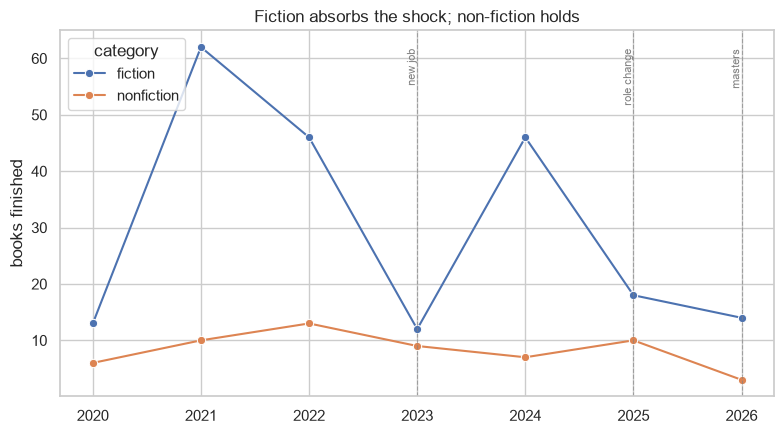

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Reshape from wide (one column per category) to long (one row per
# year-category pair) — seaborn wants long format for grouped plots.
by_year = (
    modern.groupby(["year", "category"])
    .size()
    .reset_index(name="books")
)

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.lineplot(data=by_year, x="year", y="books", hue="category",
             marker="o", ax=ax)

# Mark the transitions — the annotations are the argument, not decoration
for yr, label in [(2023, "new job"), (2025, "role change"), (2026, "masters")]:
    ax.axvline(yr, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(yr, ax.get_ylim()[1] * 0.95, label, rotation=90,
            va="top", ha="right", fontsize=8, color="grey")

ax.set_xlabel("")
ax.set_ylabel("books finished")
ax.set_title("Fiction absorbs the shock; non-fiction holds")

plt.tight_layout()
plt.savefig("../output/books_by_category.png", dpi=150)
plt.show()

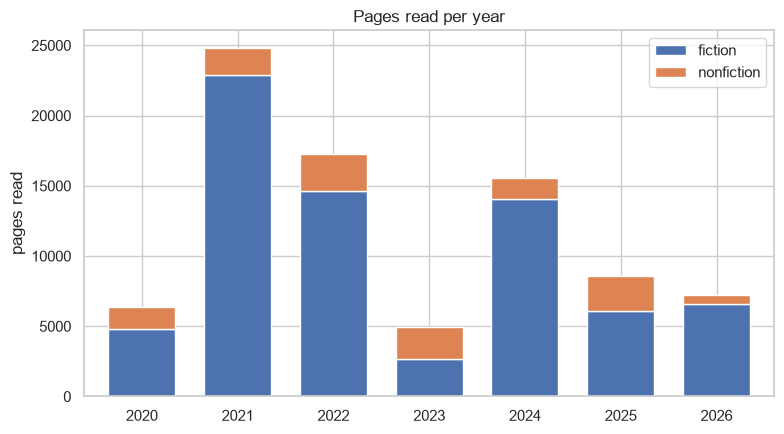

In [24]:
# Total pages per year by category. Book count understates the 2023 drop
# because the books that year were also shorter.
pages = (
    modern.dropna(subset=["Number of Pages"])
    .groupby(["year", "category"])["Number of Pages"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.5))

# Stacked bars: the two categories sum to the year's total, so you can
# read both the composition and the overall level from one chart.
pivot = pages.pivot(index="year", columns="category", values="Number of Pages")
pivot.plot(kind="bar", stacked=True, ax=ax, width=0.7)

ax.set_xlabel("")
ax.set_ylabel("pages read")
ax.set_title("Pages read per year")
ax.legend(title="")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../output/pages_by_category.png", dpi=150)
plt.show()

In [25]:
print(f"Missing page count: {modern['Number of Pages'].isna().sum()} of {len(modern)}")

Missing page count: 0 of 269
